In [1]:
from reservoir import *
from plotting import *
from experiment_functions import *
from pathlib import Path

In [2]:
# configuration
file_path = Path("../data/123824_repeated10_scale250.graphml")

# -------------------------
# physical/system parameters
# -------------------------
dt = 0.01
sigma = 10.0
rho = 28.0
beta = 8 / 3

# -------------------------
# reservoir parameters
# -------------------------
J = 0.9
input_scale = 0.5
lambda_reg = 3e-6
seed = 42

# -------------------------
# time horizons (not steps)
# -------------------------
t_thermalization = 30.0
t_training = 20000.0
t_prediction = 10.0

In [3]:
(
    washout_steps,
    train_steps,
    n_steps,
    W,
    W_in,
    W_out,
    r,
    u_tr,
    u_mean,
    u_std,
    lorenz_last_state,
    R_pred,
    Y_pred_norm,
    Y_pred,
    Y_true,
    lorenz_states,
    total_runtime,
) = run_reservoir_workflow(
    file_path=file_path,
    J=J,
    lambda_reg=lambda_reg,
    t_thermalization=t_thermalization,
    t_training=t_training,
    t_prediction=t_prediction,
    sigma=sigma,
    rho=rho,
    beta=beta,
    dt=dt,
    input_scale=input_scale,
    seed=seed,
)

setup_reservoir finished in 110.925 s
run_simulation finished in 0.056 s
lorenz_euler finished in 0.004 s
Total runtime: 110.987 s


In [4]:
t_div = t_div(Y_pred, Y_true, epsilon=1.0, dt=0.01)

Divergence time: 0.39


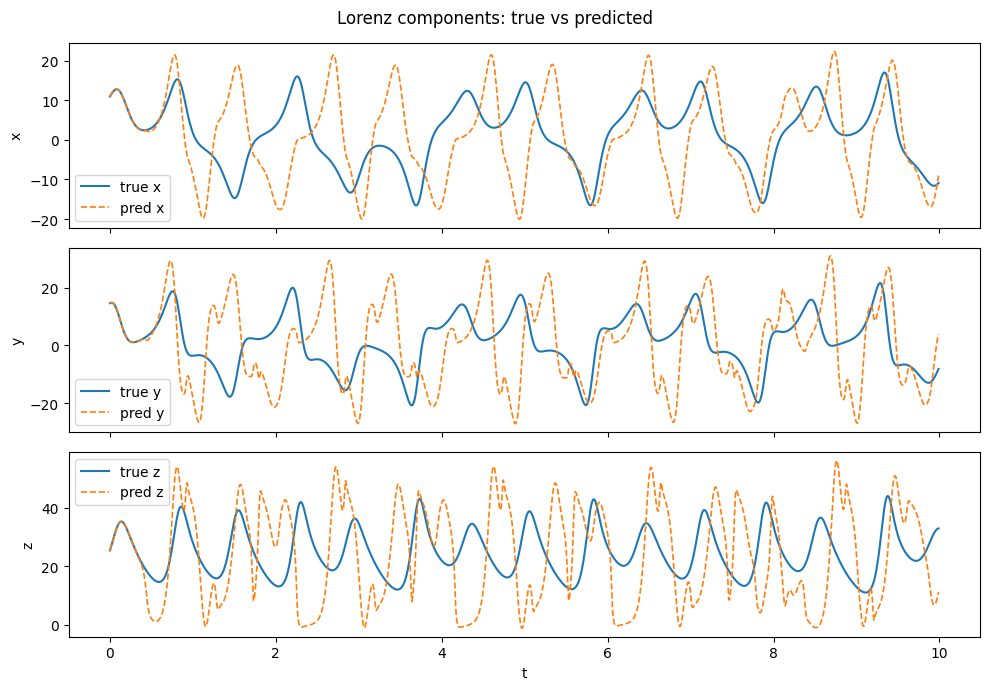

In [5]:
plot_lorenz_components(Y_pred, Y_true, dt=dt)

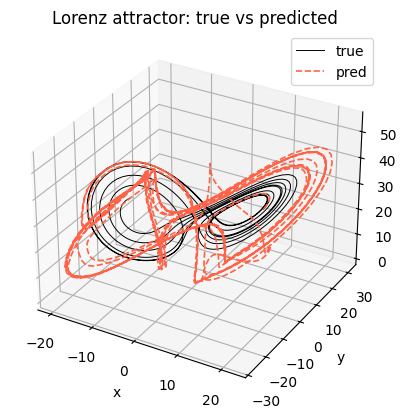

In [6]:
plot_lorenz_3d_pred_vs_true(Y_pred, Y_true)

In [8]:
# plot_lorenz_3d_interactive(Y_pred, Y_true)